# TP Machine Learning — Implémentation From Scratch

## Objectif
Suite au remarques du prof durant la séance j'ai du faire des modifications sur le TP .


Ce notebook implémente from scratch les algorithmes suivants :

- Régression linéaire univariée
- Régression linéaire multivariée
- Régression polynomiale
- Régression logistique
- KNN from scratch
- SVM linéaire from scratch

Les modèles sont codés manuellement avec `numpy``.

Pour la régression, on utilise MSE et RMSE.  
Pour la classification, on utilise log-loss, taux d'erreur et matrice de confusion.

## 1. Importation des bibliothèques

In [1]:
# NumPy permet de manipuler des tableaux numériques et de faire des calculs matriciels.
import numpy as np

# Pandas permet de créer et manipuler des DataFrames.
import pandas as pd

# Matplotlib permet de créer les graphes.
import matplotlib.pyplot as plt

## 2. Création et exportation du dataset

In [2]:
# Fixer la graine aléatoire permet d'obtenir les mêmes résultats à chaque exécution.
np.random.seed(7)

# Nombre d'observations dans le dataset.
m = 80

# Génération de la superficie des maisons entre 55 et 210 m².
superficie = np.random.randint(55, 210, m)

# Génération du nombre de chambres entre 1 et 5.
chambres = np.random.randint(1, 6, m)

# Génération de l'âge des maisons entre 0 et 35 ans.
age_maison = np.random.randint(0, 35, m)

# Génération de la distance au centre-ville entre 1 et 18 km.
distance_centre = np.round(np.random.uniform(1, 18, m), 2)

# Ajout d'un bruit aléatoire pour rendre les données plus réalistes.
bruit = np.random.normal(0, 45, m)

# Création du prix des maisons.
# Le prix augmente avec la superficie et le nombre de chambres.
# Le prix diminue avec l'âge de la maison et la distance au centre-ville.
prix = (
    250
    + 7.5 * superficie
    + 55 * chambres
    - 4.2 * age_maison
    - 18 * distance_centre
    + bruit
)

# Construction du DataFrame final.
df = pd.DataFrame({
    "superficie": superficie,
    "chambres": chambres,
    "age_maison": age_maison,
    "distance_centre": distance_centre,
    "prix": np.round(prix, 2)
})

# Exportation du dataset au format CSV.
df.to_csv("dataset_maisons.csv", index=False)

# Affichage des premières lignes.
df.head()

,superficie,chambres,age_maison,distance_centre,prix
0,80,1,33,5.46,624.33
1,122,5,21,11.36,1175.05
2,206,4,19,3.52,1880.37
3,158,1,18,4.53,1306.04
4,147,3,0,13.26,1314.35


## 3. Fonctions utilitaires

In [3]:
def split_train_test(X, y, test_ratio=0.2, seed=42):
    """Sépare manuellement les données en train/test."""
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    taille_test = int(len(X) * test_ratio)
    indices_test = indices[:taille_test]
    indices_train = indices[taille_test:]
    return X[indices_train], X[indices_test], y[indices_train], y[indices_test]


def normaliser_train_test(X_train, X_test):
    """Normalise les données avec la moyenne et l'écart-type du train."""
    moyenne = X_train.mean(axis=0)
    ecart_type = X_train.std(axis=0)
    ecart_type[ecart_type == 0] = 1
    return (X_train - moyenne) / ecart_type, (X_test - moyenne) / ecart_type, moyenne, ecart_type


def mse(y_true, y_pred):
    """Calcule l'erreur quadratique moyenne."""
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    """Calcule la racine de l'erreur quadratique moyenne."""
    return np.sqrt(mse(y_true, y_pred))


def taux_erreur(y_true, y_pred):
    """Calcule le taux d'erreur pour une classification."""
    return np.mean(y_true != y_pred)


def matrice_confusion(y_true, y_pred):
    """Calcule la matrice de confusion binaire [[TN, FP], [FN, TP]]."""
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

## 4. Régression linéaire univariée from scratch

In [4]:
def regression_lineaire_univariee(X, y, alpha=0.01, iterations=1000):
    """Régression linéaire univariée avec descente de gradient."""
    # Initialisation de la pente et du biais.
    a = 0.0
    b = 0.0

    # Nombre d'exemples.
    m = len(y)

    # Historique pour suivre la diminution du coût.
    historique_cout = []

    for i in range(iterations):
        # Hypothèse du modèle : y_pred = aX + b.
        y_pred = a * X + b

        # Erreur entre prédiction et valeur réelle.
        erreur = y_pred - y

        # Fonction de coût J(a,b) = 1/(2m) * somme(erreur²).
        cout = (1 / (2 * m)) * np.sum(erreur ** 2)
        historique_cout.append(cout)

        # Gradients selon les formules du cours.
        da = (1 / m) * np.sum(erreur * X)
        db = (1 / m) * np.sum(erreur)

        # Mise à jour des paramètres.
        a = a - alpha * da
        b = b - alpha * db

    return a, b, historique_cout

In [5]:
# Variable explicative : superficie.
X_uni = df["superficie"].values.astype(float)

# Variable cible : prix.
y_reg = df["prix"].values.astype(float)

# Séparation train/test.
X_train_u, X_test_u, y_train_u, y_test_u = split_train_test(X_uni, y_reg)

# Normalisation de la superficie.
moy_u = X_train_u.mean()
std_u = X_train_u.std()
X_train_u_norm = (X_train_u - moy_u) / std_u
X_test_u_norm = (X_test_u - moy_u) / std_u

# Entraînement.
a_uni, b_uni, couts_uni = regression_lineaire_univariee(
    X_train_u_norm, y_train_u, alpha=0.05, iterations=1500
)

# Prédictions.
y_pred_u = a_uni * X_test_u_norm + b_uni

print("Régression linéaire univariée")
print("a =", a_uni)
print("b =", b_uni)
print("MSE =", mse(y_test_u, y_pred_u))
print("RMSE =", rmse(y_test_u, y_pred_u))

Régression linéaire univariée
a = 356.068623310745
b = 1185.081718749998
MSE = 15572.2373977506
RMSE = 124.78877112044417


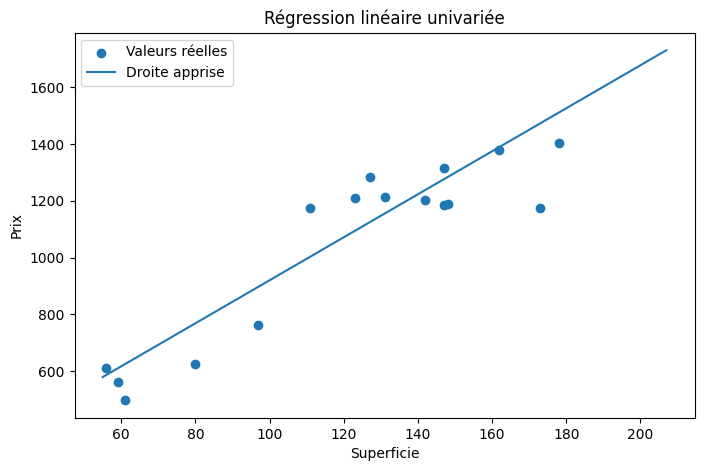

In [6]:
# Graphe de la droite de régression univariée.
plt.figure(figsize=(8, 5))

# Points réels du jeu de test.
plt.scatter(X_test_u, y_test_u, label="Valeurs réelles")

# Création d'une droite continue.
x_ligne = np.linspace(X_uni.min(), X_uni.max(), 100)
x_ligne_norm = (x_ligne - moy_u) / std_u
y_ligne = a_uni * x_ligne_norm + b_uni

# Droite apprise par le modèle.
plt.plot(x_ligne, y_ligne, label="Droite apprise")

plt.xlabel("Superficie")
plt.ylabel("Prix")
plt.title("Régression linéaire univariée")
plt.legend()

# Sauvegarde du graphe.
plt.savefig("graphe_regression_univariee.png")
plt.show()

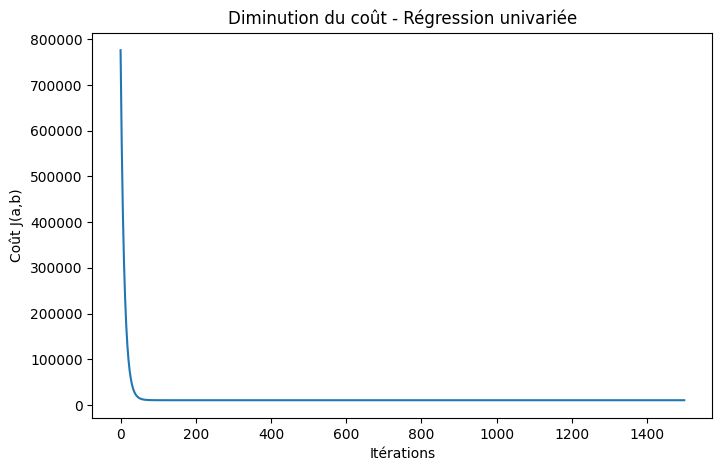

In [7]:
# Graphe de l'évolution du coût.
plt.figure(figsize=(8, 5))

# Une courbe décroissante montre que la descente de gradient converge.
plt.plot(couts_uni)

plt.xlabel("Itérations")
plt.ylabel("Coût J(a,b)")
plt.title("Diminution du coût - Régression univariée")

plt.savefig("cout_regression_univariee.png")
plt.show()

## 5. Régression linéaire multivariée from scratch

In [8]:
def regression_lineaire_multivariee(X, y, alpha=0.01, iterations=1000):
    """Régression linéaire multivariée vectorisée."""
    m = X.shape[0]

    # Ajout de la colonne de biais x0 = 1.
    X_b = np.c_[np.ones((m, 1)), X]

    # Initialisation du vecteur des poids.
    W = np.zeros((X_b.shape[1], 1))
    historique_cout = []

    for i in range(iterations):
        # Prédiction vectorisée : Y_pred = XW.
        y_pred = X_b @ W

        # Erreur.
        erreur = y_pred - y

        # Coût MSE avec facteur 1/(2m).
        cout = (1 / (2 * m)) * np.sum(erreur ** 2)
        historique_cout.append(cout)

        # Gradient vectorisé : (1/m) X.T (XW - Y).
        gradients = (1 / m) * (X_b.T @ erreur)

        # Mise à jour des poids.
        W = W - alpha * gradients

    return W, historique_cout


def predire_multivarie(X, W):
    """Prédit avec un modèle multivarié."""
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return X_b @ W

In [9]:
# Variables explicatives.
X_multi = df[["superficie", "chambres", "age_maison", "distance_centre"]].values.astype(float)

# Cible.
y_multi = df["prix"].values.reshape(-1, 1).astype(float)

# Séparation.
X_train_m, X_test_m, y_train_m, y_test_m = split_train_test(X_multi, y_multi)

# Normalisation.
X_train_m_norm, X_test_m_norm, moyenne_m, std_m = normaliser_train_test(X_train_m, X_test_m)

# Entraînement.
W_multi, couts_multi = regression_lineaire_multivariee(
    X_train_m_norm, y_train_m, alpha=0.05, iterations=2000
)

# Prédictions.
y_pred_m = predire_multivarie(X_test_m_norm, W_multi)

print("Régression linéaire multivariée")
print("W =")
print(W_multi)
print("MSE =", mse(y_test_m, y_pred_m))
print("RMSE =", rmse(y_test_m, y_pred_m))

Régression linéaire multivariée
W =
[[1185.08171875]
 [ 354.48130614]
 [  82.84365387]
 [ -45.65255142]
 [ -92.7410099 ]]
MSE = 2223.952667222211
RMSE = 47.15880264830958


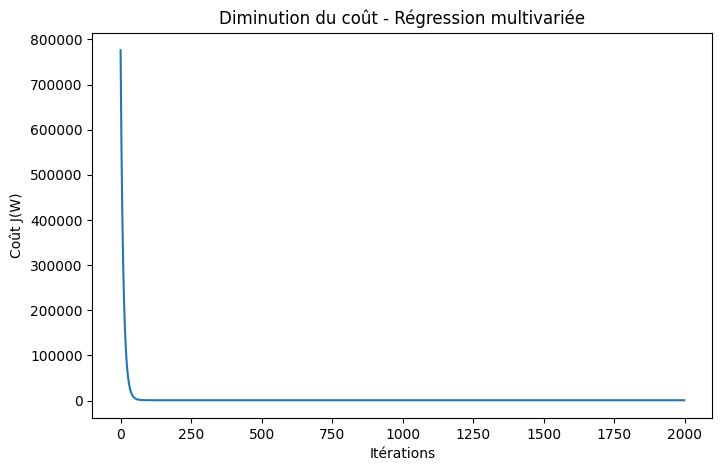

In [10]:
# Graphe de convergence de la régression multivariée.
plt.figure(figsize=(8, 5))
plt.plot(couts_multi)

plt.xlabel("Itérations")
plt.ylabel("Coût J(W)")
plt.title("Diminution du coût - Régression multivariée")

plt.savefig("cout_regression_multivariee.png")
plt.show()

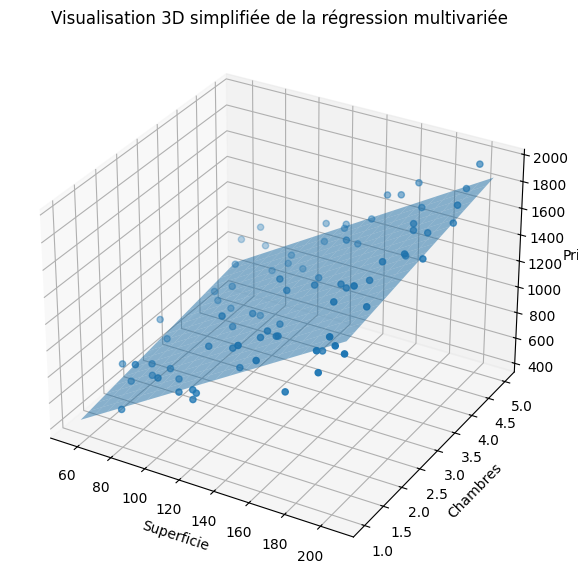

In [11]:
# Visualisation 3D simplifiée.
# Le modèle multivarié complet utilise 4 variables, donc il est impossible
# de le représenter complètement en 2D ou 3D.
# Pour visualiser le principe, on prend seulement superficie et chambres.

X_vis = df[["superficie", "chambres"]].values.astype(float)
y_vis = df["prix"].values.reshape(-1, 1).astype(float)

X_train_v, X_test_v, y_train_v, y_test_v = split_train_test(X_vis, y_vis)
X_train_v_norm, X_test_v_norm, moy_v, std_v = normaliser_train_test(X_train_v, X_test_v)

W_vis, couts_vis = regression_lineaire_multivariee(
    X_train_v_norm, y_train_v, alpha=0.05, iterations=2000
)

# Création de la grille pour afficher le plan.
x_range = np.linspace(df["superficie"].min(), df["superficie"].max(), 20)
y_range = np.linspace(df["chambres"].min(), df["chambres"].max(), 20)
xx, yy = np.meshgrid(x_range, y_range)

grille = np.c_[xx.ravel(), yy.ravel()]
grille_norm = (grille - moy_v) / std_v
zz = predire_multivarie(grille_norm, W_vis).reshape(xx.shape)

# Graphe 3D.
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df["superficie"], df["chambres"], df["prix"], label="Données réelles")
ax.plot_surface(xx, yy, zz, alpha=0.5)

ax.set_xlabel("Superficie")
ax.set_ylabel("Chambres")
ax.set_zlabel("Prix")
ax.set_title("Visualisation 3D simplifiée de la régression multivariée")

plt.savefig("graphe_regression_multivariee_3D.png")
plt.show()

## 6. Régression polynomiale from scratch

In [12]:
def creer_features_polynomiales(X, degre):
    """Crée les caractéristiques X, X², ..., X^degré."""
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    X_poly = X.copy()

    for d in range(2, degre + 1):
        X_poly = np.hstack((X_poly, X ** d))

    return X_poly


def regression_polynomiale_equation_normale(X, y, degre=2):
    """Régression polynomiale avec l'équation normale."""
    X_poly = creer_features_polynomiales(X, degre)

    # Ajout du biais.
    X_b = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]

    # Équation normale : W = (X.T X)^-1 X.T Y.
    # On utilise pinv pour éviter les problèmes d'inversion.
    W = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

    return W


def predire_polynomiale(X, W, degre):
    """Prédit avec un modèle polynomial."""
    X_poly = creer_features_polynomiales(X, degre)
    X_b = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]
    return X_b @ W

In [13]:
# Variable explicative : superficie.
X_poly_base = df["superficie"].values.reshape(-1, 1).astype(float)

# Cible.
y_poly = df["prix"].values.reshape(-1, 1).astype(float)

# Séparation.
X_train_p, X_test_p, y_train_p, y_test_p = split_train_test(X_poly_base, y_poly)

# Normalisation.
X_train_p_norm, X_test_p_norm, moy_p, std_p = normaliser_train_test(X_train_p, X_test_p)

# Degré du polynôme : y = b0 + b1*x + b2*x².
degre = 2

# Entraînement.
W_poly = regression_polynomiale_equation_normale(X_train_p_norm, y_train_p, degre=degre)

# Prédiction.
y_pred_p = predire_polynomiale(X_test_p_norm, W_poly, degre=degre)

print("Régression polynomiale")
print("W =")
print(W_poly)
print("MSE =", mse(y_test_p, y_pred_p))
print("RMSE =", rmse(y_test_p, y_pred_p))

Régression polynomiale
W =
[[1149.96371527]
 [ 355.21279585]
 [  35.11800348]]
MSE = 18438.5835417012
RMSE = 135.78874600533433


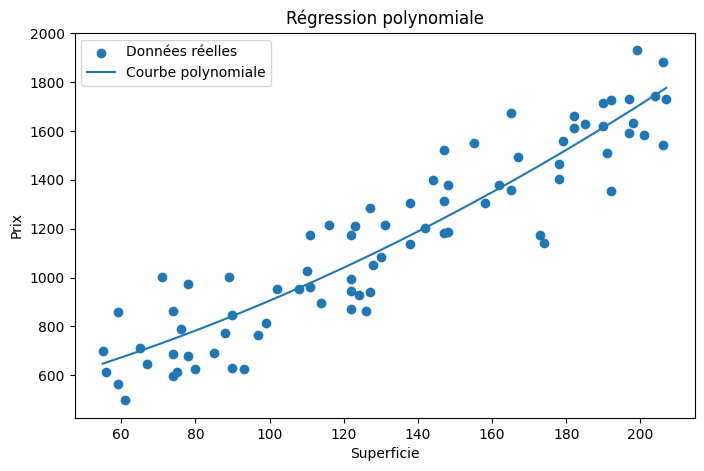

In [14]:
# Graphe de la régression polynomiale.
plt.figure(figsize=(8, 5))

# Points réels.
plt.scatter(X_poly_base, y_poly, label="Données réelles")

# Courbe lisse.
x_courbe = np.linspace(X_poly_base.min(), X_poly_base.max(), 200).reshape(-1, 1)
x_courbe_norm = (x_courbe - moy_p) / std_p
y_courbe = predire_polynomiale(x_courbe_norm, W_poly, degre=degre)

plt.plot(x_courbe, y_courbe, label="Courbe polynomiale")

plt.xlabel("Superficie")
plt.ylabel("Prix")
plt.title("Régression polynomiale")
plt.legend()

plt.savefig("graphe_regression_polynomiale.png")
plt.show()

## 7. Régression logistique from scratch

In [15]:
def sigmoid(z):
    """Transforme une valeur réelle en probabilité entre 0 et 1."""
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def log_loss(y_true, y_prob):
    """Fonction de coût de la régression logistique."""
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))


def regression_logistique(X, y, alpha=0.05, iterations=2000):
    """Régression logistique avec descente de gradient."""
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros((X_b.shape[1], 1))
    historique_cout = []

    for i in range(iterations):
        z = X_b @ theta
        probabilites = sigmoid(z)
        cout = log_loss(y, probabilites)
        historique_cout.append(cout)
        gradient = (1 / m) * (X_b.T @ (probabilites - y))
        theta = theta - alpha * gradient

    return theta, historique_cout


def predire_logistique(X, theta, seuil=0.5):
    """Prédit les classes à partir des probabilités."""
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    probabilites = sigmoid(X_b @ theta)
    classes = (probabilites >= seuil).astype(int)
    return classes, probabilites

In [16]:
# Création d'une classe binaire :
# 0 = maison moins chère que la médiane
# 1 = maison plus chère ou égale à la médiane
y_classe = (df["prix"].values.reshape(-1, 1) >= df["prix"].median()).astype(int)

X_log = df[["superficie", "chambres", "age_maison", "distance_centre"]].values.astype(float)

X_train_l, X_test_l, y_train_l, y_test_l = split_train_test(X_log, y_classe)
X_train_l_norm, X_test_l_norm, moy_l, std_l = normaliser_train_test(X_train_l, X_test_l)

theta_log, couts_log = regression_logistique(
    X_train_l_norm, y_train_l, alpha=0.1, iterations=2500
)

y_pred_l, prob_l = predire_logistique(X_test_l_norm, theta_log)

print("Régression logistique")
print("Log-loss =", log_loss(y_test_l, prob_l))
print("Taux d'erreur =", taux_erreur(y_test_l, y_pred_l))
print("Matrice de confusion :")
print(matrice_confusion(y_test_l, y_pred_l))

Régression logistique
Log-loss = 0.39874477989102675
Taux d'erreur = 0.1875
Matrice de confusion :
[[5 1]
 [2 8]]


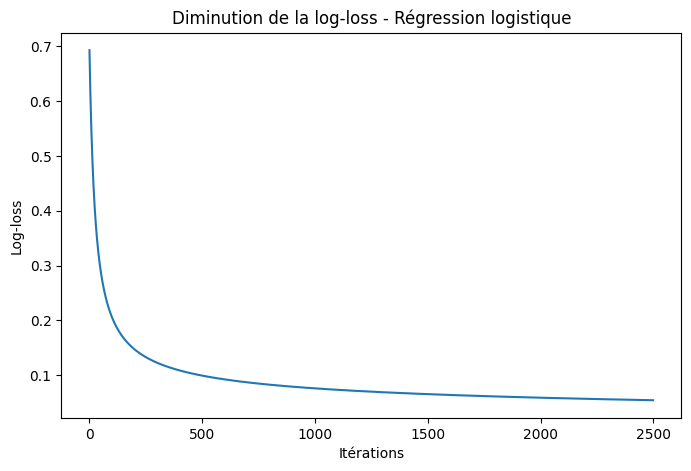

In [17]:
# Graphe de la log-loss.
plt.figure(figsize=(8, 5))
plt.plot(couts_log)

plt.xlabel("Itérations")
plt.ylabel("Log-loss")
plt.title("Diminution de la log-loss - Régression logistique")

plt.savefig("cout_regression_logistique.png")
plt.show()

## 8. KNN from scratch

In [18]:
def distance_euclidienne(p, q):
    """Calcule la distance euclidienne entre deux points."""
    return np.sqrt(np.sum((p - q) ** 2))


class KNNRegresseurFromScratch:
    """KNN pour la régression."""
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # Le KNN mémorise les données d'entraînement.
        self.X_train = X
        self.y_train = y

    def predict_one(self, x):
        # Distance entre x et tous les points du train.
        distances = np.array([distance_euclidienne(x, x_train) for x_train in self.X_train])

        # Sélection des k plus proches voisins.
        indices_voisins = np.argsort(distances)[:self.k]
        valeurs_voisins = self.y_train[indices_voisins]

        # Pour la régression : moyenne des valeurs des voisins.
        return np.mean(valeurs_voisins)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X]).reshape(-1, 1)


class KNNClassifieurFromScratch:
    """KNN pour la classification."""
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.flatten()

    def predict_one(self, x):
        distances = np.array([distance_euclidienne(x, x_train) for x_train in self.X_train])
        indices_voisins = np.argsort(distances)[:self.k]
        classes_voisins = self.y_train[indices_voisins]

        # Pour la classification : vote majoritaire.
        return np.bincount(classes_voisins).argmax()

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X]).reshape(-1, 1)

In [19]:
# KNN régression.
knn_reg = KNNRegresseurFromScratch(k=5)
knn_reg.fit(X_train_m_norm, y_train_m)

y_pred_knn_reg = knn_reg.predict(X_test_m_norm)

print("KNN régression from scratch")
print("MSE =", mse(y_test_m, y_pred_knn_reg))
print("RMSE =", rmse(y_test_m, y_pred_knn_reg))

KNN régression from scratch
MSE = 26428.132023749997
RMSE = 162.5673153612066


In [20]:
# KNN classification.
knn_clf = KNNClassifieurFromScratch(k=5)
knn_clf.fit(X_train_l_norm, y_train_l)

y_pred_knn_clf = knn_clf.predict(X_test_l_norm)

print("KNN classification from scratch")
print("Taux d'erreur =", taux_erreur(y_test_l, y_pred_knn_clf))
print("Matrice de confusion :")
print(matrice_confusion(y_test_l, y_pred_knn_clf))

KNN classification from scratch
Taux d'erreur = 0.375
Matrice de confusion :
[[5 1]
 [5 5]]


## 9. SVM linéaire from scratch

In [21]:
class SVMLineaireFromScratch:
    """SVM linéaire from scratch avec hinge loss."""
    def __init__(self, alpha=0.001, lambda_param=0.01, iterations=2000):
        self.alpha = alpha
        self.lambda_param = lambda_param
        self.iterations = iterations
        self.w = None
        self.b = None
        self.historique_cout = []

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0

        for iteration in range(self.iterations):
            # Marge : y(w.x + b).
            marges = y * (X @ self.w + self.b)

            # Hinge loss : max(0, 1 - marge).
            hinge = np.maximum(0, 1 - marges)

            # Coût avec régularisation L2.
            cout = self.lambda_param * np.sum(self.w ** 2) + np.mean(hinge)
            self.historique_cout.append(cout)

            # Descente de gradient exemple par exemple.
            for i in range(m):
                condition = y[i] * (np.dot(X[i], self.w) + self.b) >= 1

                if condition:
                    # Si la marge est respectée, seule la régularisation agit.
                    self.w = self.w - self.alpha * (2 * self.lambda_param * self.w)
                else:
                    # Sinon, on corrige l'hyperplan.
                    self.w = self.w - self.alpha * (2 * self.lambda_param * self.w - y[i] * X[i])
                    self.b = self.b + self.alpha * y[i]

    def predict(self, X):
        decision = X @ self.w + self.b
        return np.where(decision >= 0, 1, -1)

In [22]:
# Le SVM utilise les classes -1 et +1.
y_svm = np.where(y_train_l.flatten() == 0, -1, 1)
y_test_svm = np.where(y_test_l.flatten() == 0, -1, 1)

svm = SVMLineaireFromScratch(alpha=0.001, lambda_param=0.01, iterations=2000)
svm.fit(X_train_l_norm, y_svm)

y_pred_svm = svm.predict(X_test_l_norm)

# Conversion en 0/1 pour la matrice de confusion.
y_test_svm_01 = np.where(y_test_svm == -1, 0, 1).reshape(-1, 1)
y_pred_svm_01 = np.where(y_pred_svm == -1, 0, 1).reshape(-1, 1)

print("SVM linéaire from scratch")
print("Taux d'erreur =", taux_erreur(y_test_svm_01, y_pred_svm_01))
print("Matrice de confusion :")
print(matrice_confusion(y_test_svm_01, y_pred_svm_01))

SVM linéaire from scratch
Taux d'erreur = 0.25
Matrice de confusion :
[[5 1]
 [3 7]]


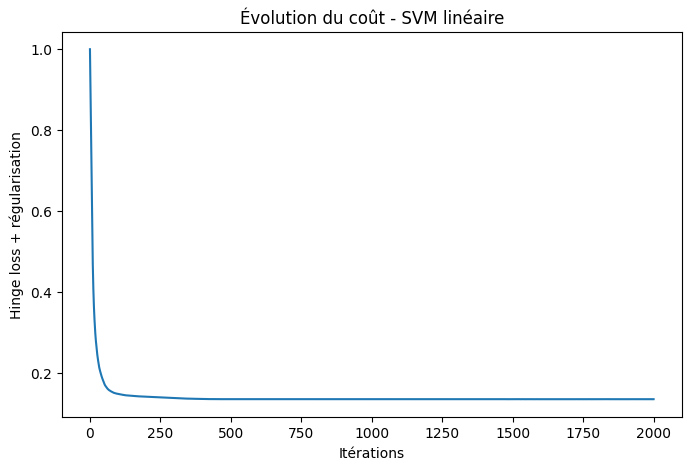

In [23]:
# Graphe du coût SVM.
plt.figure(figsize=(8, 5))
plt.plot(svm.historique_cout)

plt.xlabel("Itérations")
plt.ylabel("Hinge loss + régularisation")
plt.title("Évolution du coût - SVM linéaire")

plt.savefig("cout_svm_lineaire.png")
plt.show()

## 10. Tableaux comparatifs

In [24]:
# Comparaison des modèles de régression avec MSE et RMSE.
comparaison_regression = pd.DataFrame({
    "Modèle": [
        "Régression linéaire univariée",
        "Régression linéaire multivariée",
        "Régression polynomiale",
        "KNN régression"
    ],
    "MSE": [
        mse(y_test_u, y_pred_u),
        mse(y_test_m, y_pred_m),
        mse(y_test_p, y_pred_p),
        mse(y_test_m, y_pred_knn_reg)
    ],
    "RMSE": [
        rmse(y_test_u, y_pred_u),
        rmse(y_test_m, y_pred_m),
        rmse(y_test_p, y_pred_p),
        rmse(y_test_m, y_pred_knn_reg)
    ]
})

comparaison_regression

,Modèle,MSE,RMSE
0,Régression linéaire univariée,15572.237398,124.788771
1,Régression linéaire multivariée,2223.952667,47.158803
2,Régression polynomiale,18438.583542,135.788746
3,KNN régression,26428.132024,162.567315


In [25]:
# Comparaison des modèles de classification.
comparaison_classification = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "KNN classification",
        "SVM linéaire"
    ],
    "Mesure": [
        "Log-loss + taux d'erreur + matrice de confusion",
        "Taux d'erreur + matrice de confusion",
        "Taux d'erreur + matrice de confusion"
    ],
    "Taux d'erreur": [
        taux_erreur(y_test_l, y_pred_l),
        taux_erreur(y_test_l, y_pred_knn_clf),
        taux_erreur(y_test_svm_01, y_pred_svm_01)
    ]
})

comparaison_classification

,Modèle,Mesure,Taux d'erreur
0,Régression logistique,Log-loss + taux d'erreur + matrice de confusion,0.1875
1,KNN classification,Taux d'erreur + matrice de confusion,0.3750
2,SVM linéaire,Taux d'erreur + matrice de confusion,0.2500
